# Business Understanding

## Business Problem

Customer churn is one of the biggest challenges faced by subscription-based businesses such as telecommunications companies. Losing existing customers not only reduces revenue but also increases the cost of acquiring new customers.

The objective of this project is to develop a machine learning model that can accurately predict whether a customer is likely to churn. By identifying high-risk customers in advance, the company can implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss.

## Business Objectives

- Predict whether a customer will churn.
- Identify the key factors that influence customer churn.
- Provide actionable business insights for customer retention.
- Support decision-making with data-driven recommendations.

# Dataset Overview

## Dataset Summary

This dataset contains customer information collected from a telecommunications company.

- **Number of Records:** 7,043
- **Number of Features:** 33
- **Target Variable:** Churn Value

Each row represents a unique customer, while each column describes a specific customer characteristic such as demographic information, subscribed services, billing details, or churn status.

## Feature Categories
| Category               | Description                                                                                    |
| ---------------------- | ---------------------------------------------------------------------------------------------- |
| Customer Information   | Gender, Senior Citizen, Partner, Dependents                                                    |
| Geographic Information | Country, State, City, Zip Code, Latitude, Longitude                                            |
| Subscription Services  | Phone Service, Internet Service, Online Security, Tech Support, Streaming TV, Streaming Movies |
| Billing Information    | Contract, Payment Method, Monthly Charge, Total Charges                                        |
| Customer Relationship  | Tenure Months                                                                                  |
| Target Variable        | Churn Value                                                                                    |


## Target Variable
The target variable is **Churn Value**, where:

- **0** indicates that the customer remained with the company.
- **1** indicates that the customer left the company.

## Initial Assumptions
Before building the predictive model, several assumptions can be made:

- Customers with month-to-month contracts may have a higher churn rate.
- Customers with shorter tenure are more likely to leave.
- Higher monthly charges may increase the likelihood of churn.
- Customers without additional services such as online security or technical support may be more likely to churn.

# Import Libraries

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Load the Dataset

In [13]:
df = pd.read_excel(r"..\data\raw_data.xlsx")

# Initial Data Exploration

## Display the First Five Records

In [15]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


## Display a Random Sample

In [16]:
df.sample(5, random_state=42)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
185,2189-WWOEW,1,United States,California,Keene,93531,"35.214982, -118.59049",35.21,-118.59,Female,No,No,No,15,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),85.90,1269.55,Yes,1,96,3579,Don't know
2715,2446-ZKVAF,1,United States,California,Stockton,95207,"38.002125, -121.324979",38.00,-121.32,Male,No,Yes,No,18,Yes,Yes,DSL,No,Yes,No,No,No,No,Month-to-month,No,Credit card (automatic),56.80,1074.65,No,0,59,5558,NaN
3825,4986-MXSFP,1,United States,California,San Leandro,94579,"37.687264, -122.15728",37.69,-122.16,Female,No,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.00,40.90,No,0,39,2237,NaN
1807,5868-YWPDW,1,United States,California,Sherman Oaks,91423,"34.146957, -118.432138",34.15,-118.43,Male,Yes,Yes,No,6,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.20,519.15,Yes,1,72,5834,Limited range of services
132,9412-GHEEC,1,United States,California,Murrieta,92563,"33.581045, -117.14719",33.58,-117.15,Male,No,No,No,40,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,No,Bank transfer (automatic),104.80,4131.95,Yes,1,88,3492,Service dissatisfaction


## Dataset Dimensions

In [17]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Features: {df.shape[1]-1}")

Rows    : 7043
Columns : 33
Features: 32


## Data Types and General Information

In [18]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
CustomerID,object,0,7043
Count,int64,0,1
Country,object,0,1
State,object,0,1
City,object,0,1129
Zip Code,int64,0,1652
Lat Long,object,0,1652
Latitude,float64,0,1652
Longitude,float64,0,1651
Gender,object,0,2


## Data Summary

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Zip Code,7043.00,93521.96,1865.79,90001.00,92102.00,93552.00,95351.00,96161.00
Latitude,7043.00,36.28,2.46,32.56,34.03,36.39,38.22,41.96
Longitude,7043.00,-119.80,2.16,-124.30,-121.82,-119.73,-118.04,-114.19
Tenure Months,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
Monthly Charges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
Churn Value,7043.00,0.27,0.44,0.00,0.00,0.00,1.00,1.00
Churn Score,7043.00,58.70,21.53,5.00,40.00,61.00,75.00,100.00
CLTV,7043.00,4400.30,1183.06,2003.00,3469.00,4527.00,5380.50,6500.00


In [20]:
df.describe(include="object").T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


## Missing Values Analysis

In [21]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values = missing_values[missing_values["Missing Values"] > 0]

missing_values.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Churn Reason,5174,73.46


## Duplicate Records Analysis

In [22]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


## Unique Values Analysis

In [23]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values.sort_values("Unique Values")

,Unique Values
Count,1
Country,1
State,1
Phone Service,2
Dependents,2
Partner,2
Senior Citizen,2
Gender,2
Churn Value,2
Paperless Billing,2


## Target Variable Distribution

In [27]:
target_distribution = pd.DataFrame({
    "Count": df["Churn Value"].value_counts(),
    "Percentage": df["Churn Value"].value_counts(normalize=True) * 100
})

target_distribution

,Count,Percentage
Churn Value,,
0,5174,73.46
1,1869,26.54


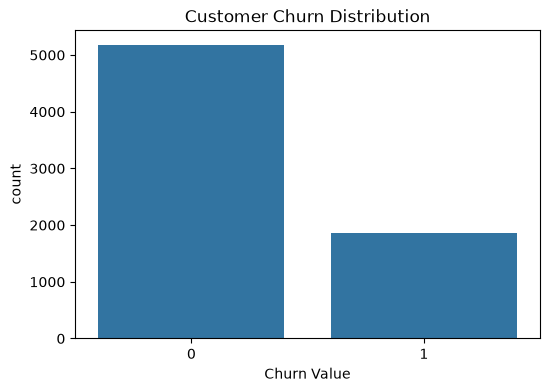

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn Value")

plt.title("Customer Churn Distribution")
plt.show()

# Initial Observations

In [30]:
df.groupby("Churn Value")["Monthly Charges"].mean()

Churn Value
0   61.27
1   74.44
Name: Monthly Charges, dtype: float64

In [31]:
df.groupby("Churn Value")["Tenure Months"].mean()

Churn Value
0   37.57
1   17.98
Name: Tenure Months, dtype: float64

In [32]:
pd.crosstab(df["Contract"], df["Churn Value"])

Churn Value,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [33]:
pd.crosstab(df["Contract"], df["Churn Value"])

Churn Value,0,1
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [34]:
pd.crosstab(df["Payment Method"], df["Churn Value"])

Churn Value,0,1
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


### Key Findings

- The dataset contains 7,043 customer records and 33 features.
- Both numerical and categorical variables are available.
- The target variable is binary, making this a binary classification problem.
- Some features may not be suitable for model training due to potential data leakage (e.g., Churn Score and Churn Reason).
- CustomerID is a unique identifier and will not contribute to predictive performance.
- Further data cleaning and preprocessing are required before exploratory data analysis and model development.